## Import Required Libraries

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from scipy.cluster.hierarchy import dendrogram, linkage

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import itertools

## Load Wheat Seeds Dataset

In [ ]:
feature_names = ['Area', 'Perimeter', 'Compactness', 'Kernel-Length', 'Kernel-Width', 'Asymmetry-Coeff', 'Kernel-Groove', 'Type']
dataset = pd.read_csv('https://github.com/jbrownlee/Datasets/raw/master/wheat-seeds.csv', names=feature_names)
dataset['Type'].replace({1:'Kama', 2: 'Rosa', 3:'Canadian'}, inplace = True)

X = dataset.iloc[:, :-1].values  # input
y = dataset.iloc[:, -1].values  # target

dataset.sample(5)

,Area,Perimeter,Compactness,Kernel-Length,Kernel-Width,Asymmetry-Coeff,Kernel-Groove,Type
173,11.40,13.08,0.8375,5.136,2.763,5.588,5.089,Canadian
121,18.14,16.12,0.8772,6.059,3.563,3.619,6.011,Rosa
160,12.54,13.67,0.8425,5.451,2.879,3.082,5.491,Canadian
45,13.80,14.04,0.8794,5.376,3.155,1.560,4.961,Kama
77,20.71,17.23,0.8763,6.579,3.814,4.451,6.451,Rosa


## Generate Descriptive Statistics

In [ ]:
dataset.describe()

,Area,Perimeter,Compactness,Kernel-Length,Kernel-Width,Asymmetry-Coeff,Kernel-Groove
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


## Check Missing Values

In [ ]:
dataset.isnull().sum()

Area               0
Perimeter          0
Compactness        0
Kernel-Length      0
Kernel-Width       0
Asymmetry-Coeff    0
Kernel-Groove      0
Type               0
dtype: int64

## Check Number of Samples in Each Class

<Axes: >

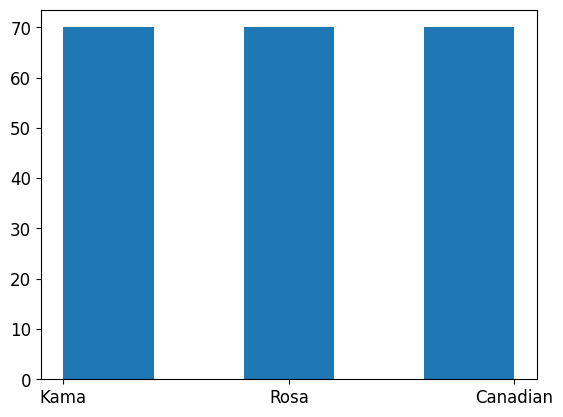

In [ ]:
dataset['Type'].hist(xlabelsize=12, ylabelsize=12, bins=5, grid=False)

## Plot Pairplot of the Dataset

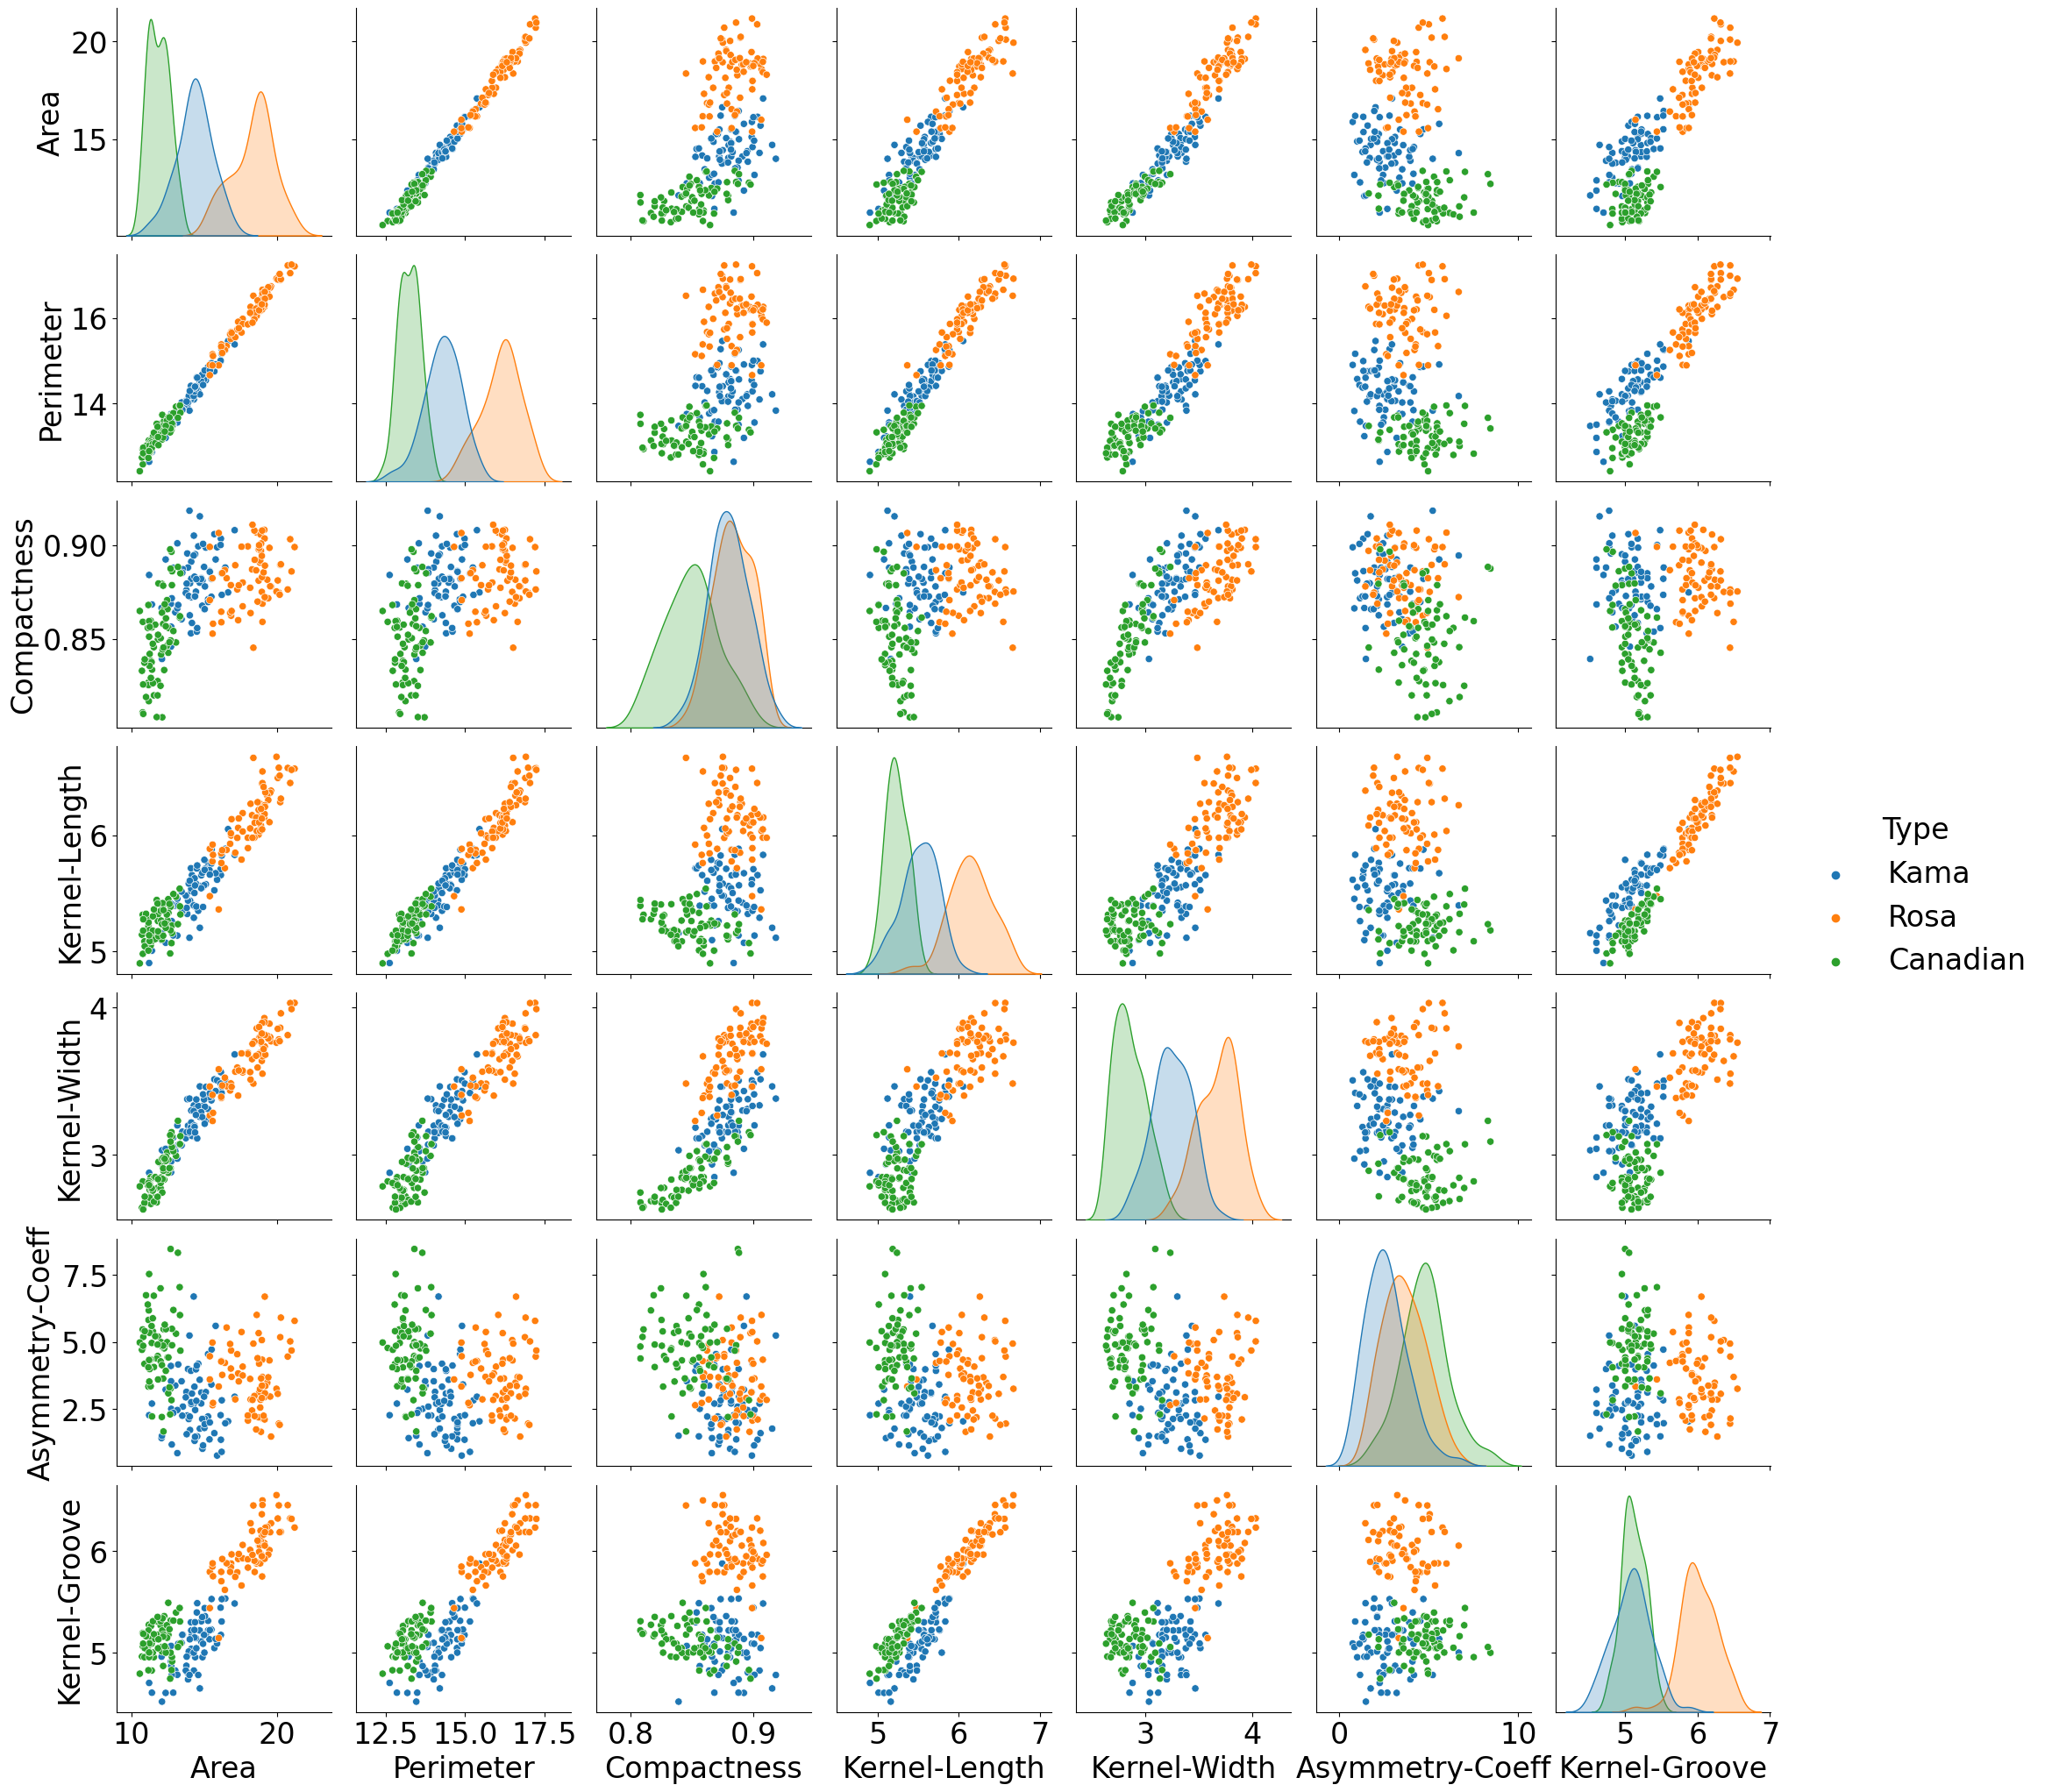

In [ ]:
plt.rc('font', size=24)
sns.pairplot(dataset, height=3, diag_kind='kde', hue='Type')

## Plot the Correlation Matrix of the Dataset

<ipython-input-7-d10af4eb8f5d>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = dataset.corr()


<Axes: >

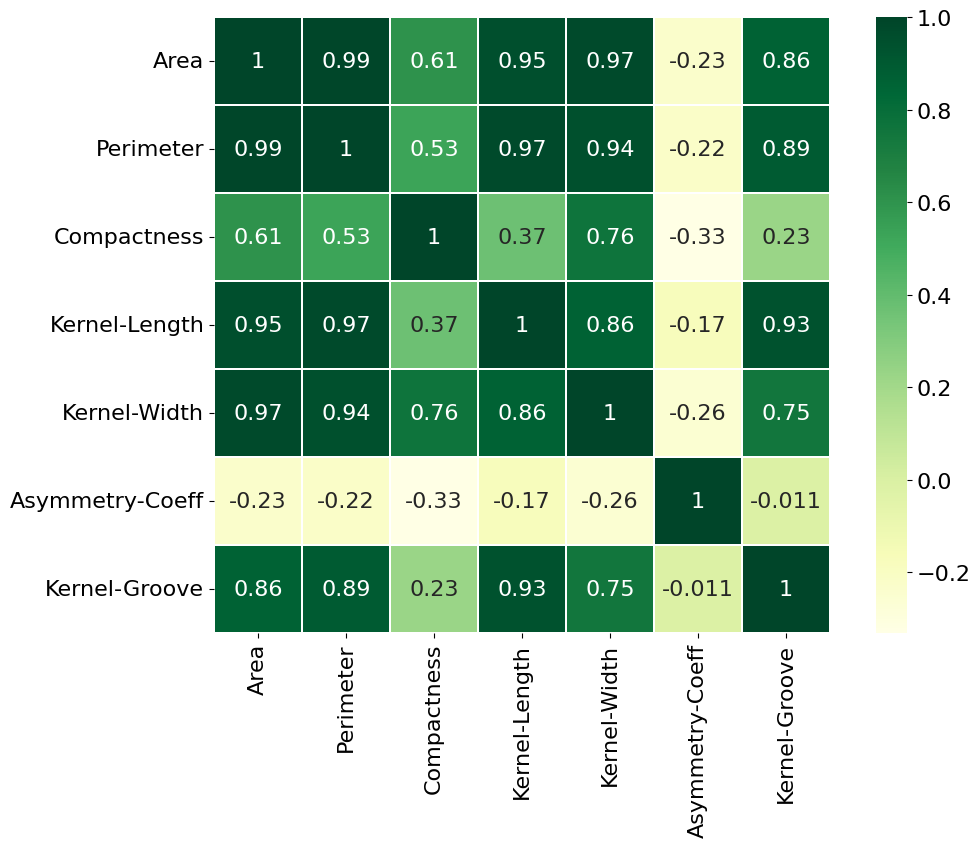

In [ ]:
corr = dataset.corr()

plt.rc('font', size=16)
f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, cmap="YlGn", square=True, ax=ax, annot=True, linewidth = 0.1)

## Plot Boxplots of Each of the Features vs Classes

### Feature: Area

<Axes: xlabel='Type', ylabel='Area'>

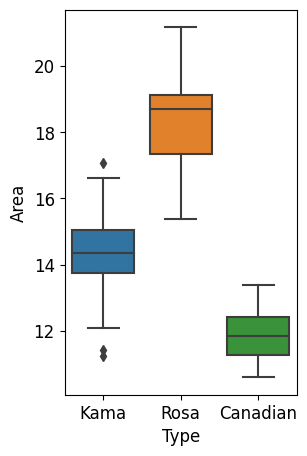

In [ ]:
plt.rc('font', size=12)
plt.figure(figsize=(3, 5))
sns.boxplot(x="Type", y="Area", data=dataset)

### Feature: Perimeter

<Axes: xlabel='Type', ylabel='Perimeter'>

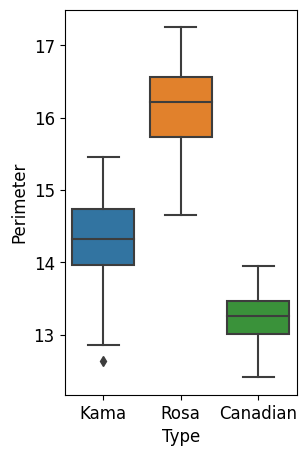

In [ ]:
plt.rc('font', size=12)
plt.figure(figsize=(3, 5))
sns.boxplot(x="Type", y="Perimeter", data=dataset)

### Feature: Compactness

<Axes: xlabel='Type', ylabel='Compactness'>

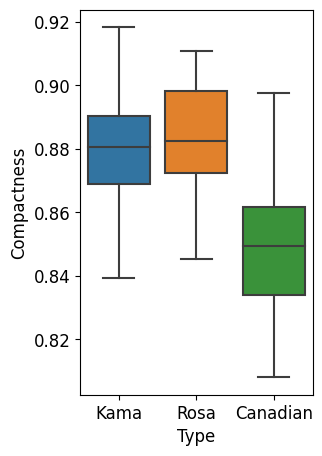

In [ ]:
plt.rc('font', size=12)
plt.figure(figsize=(3,5))
sns.boxplot(x="Type",y="Compactness", data=dataset)

### Feature: Kernel Length

<Axes: xlabel='Type', ylabel='Kernel-Length'>

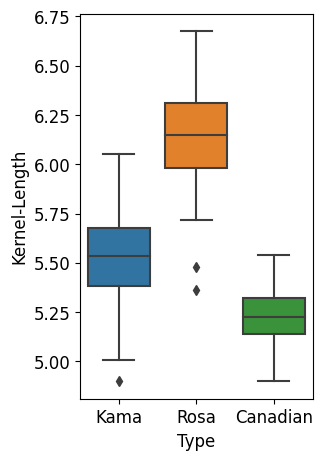

In [ ]:
plt.rc('font', size=12)
plt.figure(figsize=(3, 5))
sns.boxplot(x="Type", y="Kernel-Length", data=dataset)

### Feature: Kernel Width

<Axes: xlabel='Type', ylabel='Kernel-Width'>

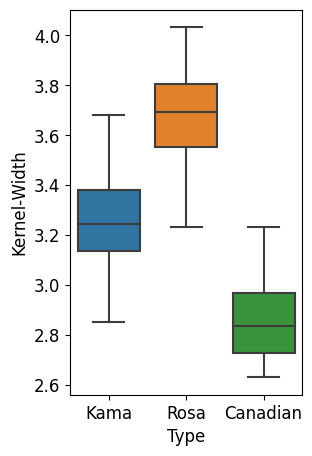

In [ ]:
plt.rc('font', size=12)
plt.figure(figsize=(3, 5))
sns.boxplot(x="Type", y="Kernel-Width", data=dataset)

### Feature: Asymmetry Coefficient

<Axes: xlabel='Type', ylabel='Asymmetry-Coeff'>

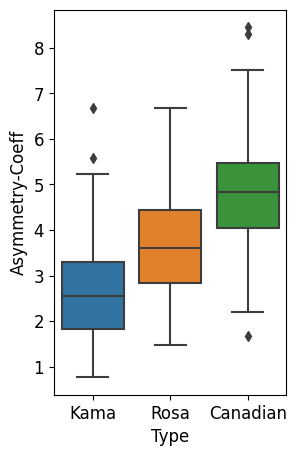

In [ ]:
plt.rc('font', size=12)
plt.figure(figsize=(3, 5))
sns.boxplot(x="Type", y="Asymmetry-Coeff", data=dataset)

### Feature: Kernel Groove

<Axes: xlabel='Type', ylabel='Kernel-Groove'>

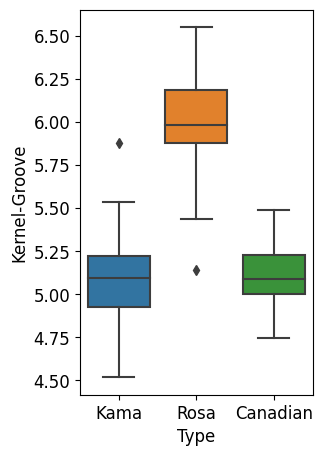

In [ ]:
plt.rc('font', size=12)
plt.figure(figsize=(3, 5))
sns.boxplot(x="Type", y="Kernel-Groove", data=dataset)

## Random Forest Classification

### Define Some Functions

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Oranges):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    Source: http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    # Plot the confusion matrix
    plt.figure(figsize = (8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, size = 24)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    # Labeling the plot
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 24,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    # plt.grid(None)
    plt.tight_layout()
    plt.ylabel('True label', size = 18)
    plt.xlabel('Predicted label', size = 18)

### Train and Plot Confusion Matrix of the Predicted Labels

Confusion matrix, without normalization


1.0

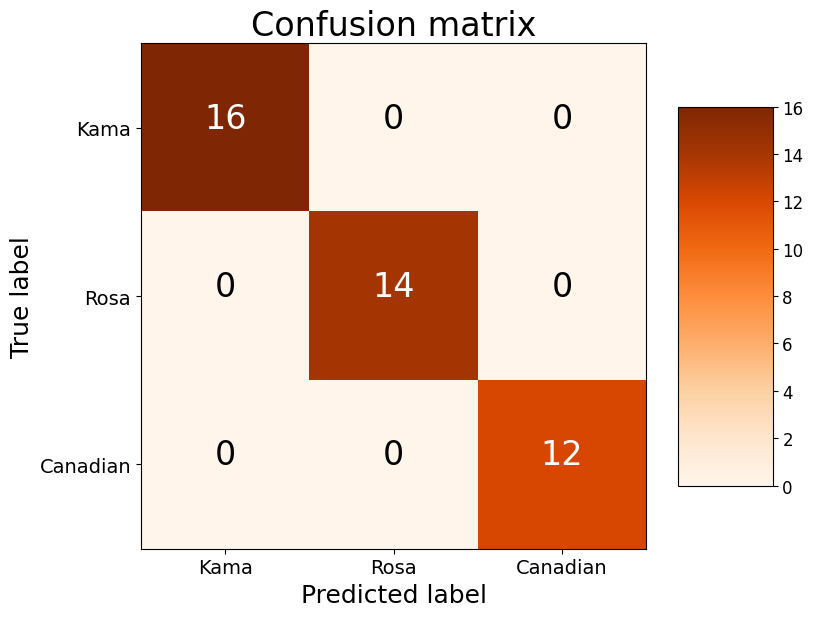

In [ ]:
clf = RandomForestClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
clf.fit(X_train, y_train)

cm = confusion_matrix(y_test, clf.predict(X_test))
plot_confusion_matrix(cm, classes=['Kama', 'Rosa', 'Canadian'])
clf.score(X_test, y_test)

### Average Normalized Predictions from 1,000 Splits

Normalized confusion matrix


0.9271428571428574

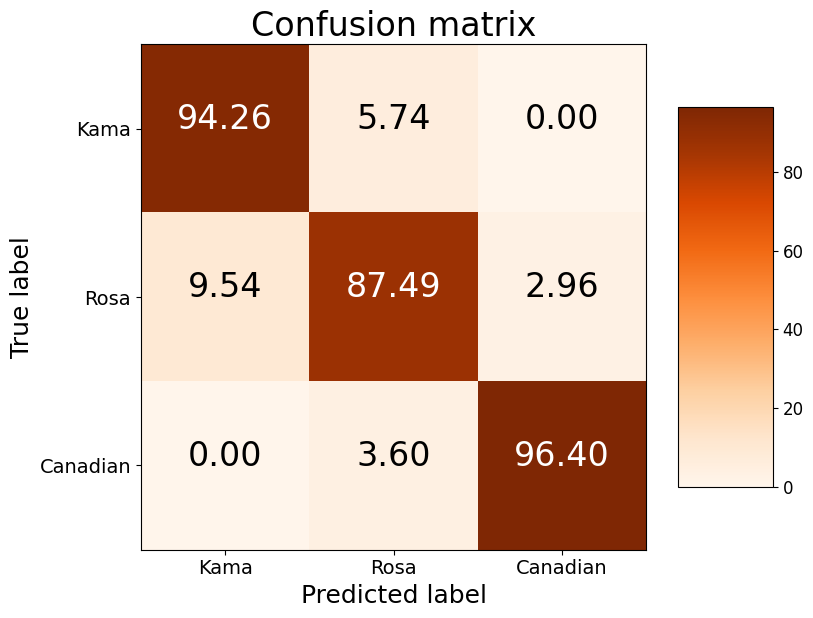

In [ ]:
scores = []
cms = []

for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

    clf = RandomForestClassifier()
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    scores.append(score)

    cm = confusion_matrix(y_test, clf.predict(X_test))
    cms.append(cm)

plot_confusion_matrix(np.mean(np.array(cms), axis=0), normalize=True, classes=['Kama', 'Rosa', 'Canadian'])
np.mean(np.array(scores))

## Hierachical Clustering

### Define Some Functions

In [ ]:
def plot_clustering(X_reduced, labels, classes, y, title=None):
    x_min, x_max = np.min(X_reduced, axis=0), np.max(X_reduced, axis=0)
    X_reduced = (X_reduced - x_min) / (x_max - x_min)

    plt.figure(figsize=(10, 8))
    for cls in classes:
        plt.scatter(
            *X_reduced[y == cls].T,
            marker=f"${cls}$",
            s=150,
            c=plt.cm.nipy_spectral(labels[y == cls] / 10),
            alpha=0.5,
        )

    plt.xticks([])
    plt.yticks([])
    if title is not None:
        plt.title(title, size=17)
    plt.axis("off")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

### Plot Clusters of Training Result (PCA)

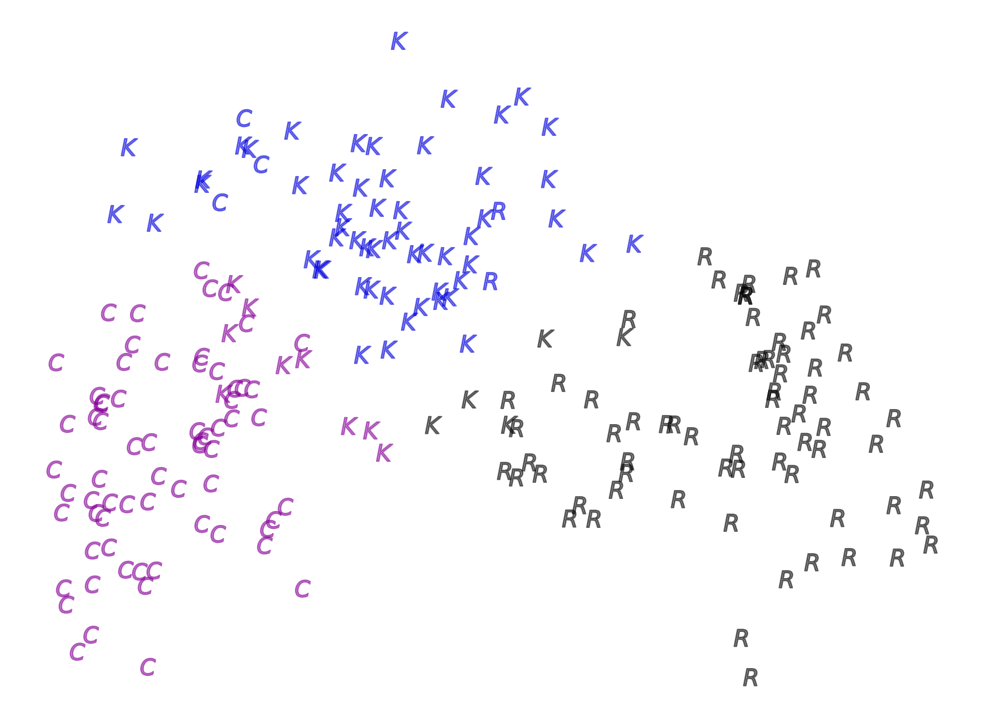

In [ ]:
norm_X = StandardScaler().fit_transform(X)  # normalized X

clt = AgglomerativeClustering(n_clusters=3)
X_reduced = PCA(n_components=2).fit_transform(norm_X)
clt.fit(X_reduced)

_y = dataset['Type'].replace({'Kama': 'K', 'Rosa': 'R', 'Canadian': 'C'})
plot_clustering(X_reduced, clt.labels_, ['K', 'R', 'C'], _y)

### Plot Dendrogram

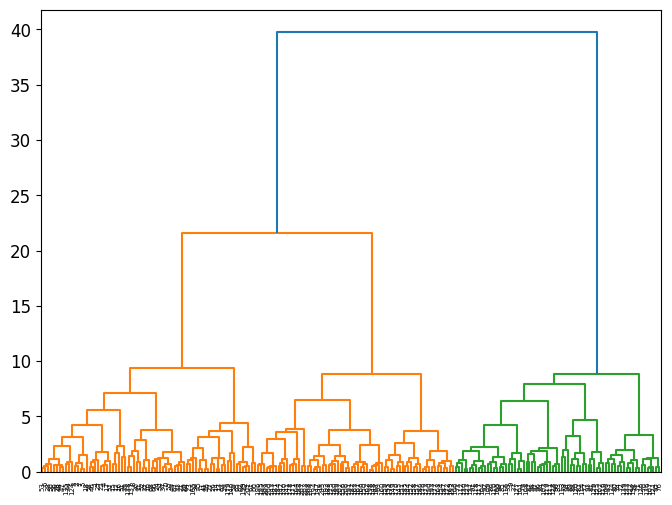

In [ ]:
links = linkage(norm_X, 'ward')

plt.figure(figsize=(8, 6))
dendrogram(links, orientation='top', truncate_mode="level", distance_sort='descending', show_leaf_counts=True)
plt.show()

### Plot Confusion Matrix Using the First Two Pricipal Components (PCA)

Confusion matrix, without normalization


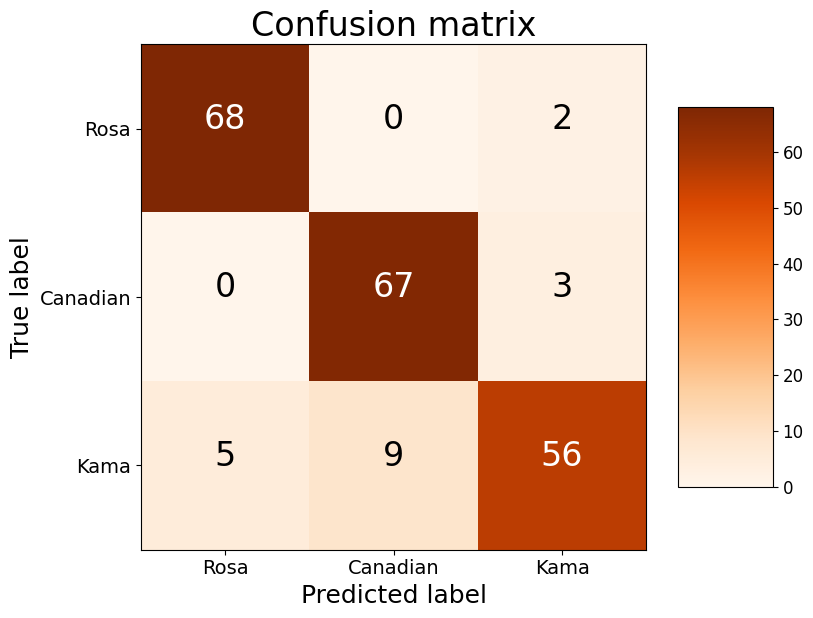

In [ ]:
norm_X = StandardScaler().fit_transform(X)  # normalized X
clt = AgglomerativeClustering(n_clusters=3)
X_reduced = PCA(n_components=2).fit_transform(norm_X)
clt.fit(X_reduced)

cls_names = ['Kama', 'Rosa', 'Canadian']
labels = []
for cls in cls_names:
  counts = np.bincount(clt.labels_[y == cls])
  label = np.argmax(counts)
  labels.append(label)

_y = dataset['Type'].replace(dict(zip(cls_names, labels))).values
cm = confusion_matrix(_y, clt.labels_)
_cls_names = [x[0] for x in sorted(zip(cls_names, labels), key=lambda x: x[1])]
plot_confusion_matrix(cm, normalize=False, classes=_cls_names)

### Plot Confusion Matrix Using All Features

Confusion matrix, without normalization


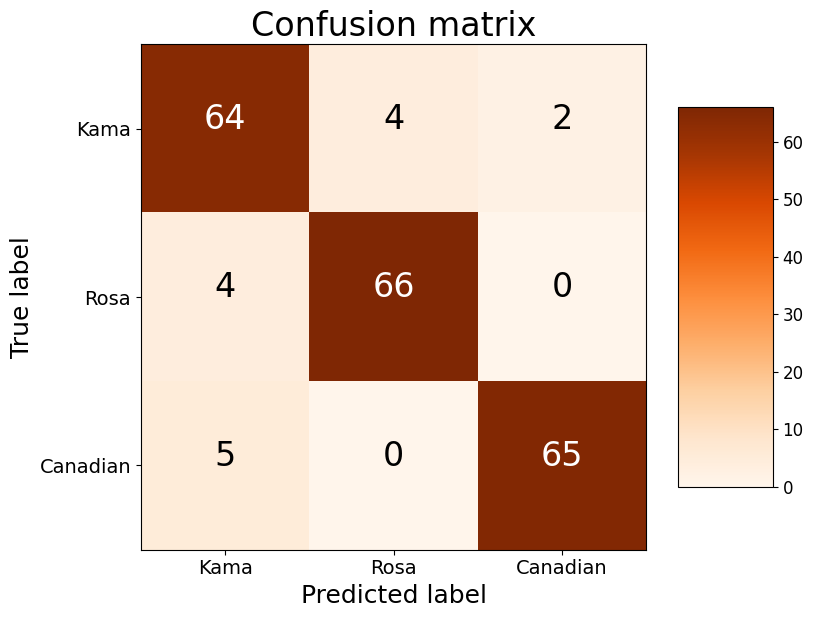

In [ ]:
norm_X = StandardScaler().fit_transform(X)  # normalized X

clt = AgglomerativeClustering(n_clusters=3)
clt.fit(norm_X)

cls_names = ['Kama', 'Rosa', 'Canadian']
labels = []
for cls in cls_names:
  counts = np.bincount(clt.labels_[y == cls])
  label = np.argmax(counts)
  labels.append(label)

_y = dataset['Type'].replace(dict(zip(cls_names, labels))).values
cm = confusion_matrix(_y, clt.labels_)
_cls_names = [x[0] for x in sorted(zip(cls_names, labels), key=lambda x: x[1])]
plot_confusion_matrix(cm, normalize=False, classes=_cls_names)